In [38]:
from huggingface_hub import notebook_login
notebook_login()


In [39]:
import pandas as pd
import numpy as np
import torch
from transformers import AutoTokenizer, AutoModelForMaskedLM
from datasets import load_dataset
import matplotlib.pyplot as plt
import random
from tqdm import tqdm


RANDOM_SEED = 42

def seed_everything(seed=42):
    random.seed(seed) 
    np.random.seed(seed)
    
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(42)

splits = {'train': 'train.csv', 'validation': 'dev.csv', 'test': 'test.csv'}

train_df = pd.read_csv("hf://datasets/uitnlp/vihsd/" + splits["train"])
drop_idx = train_df[train_df["label_id"] == 0].index[2000:]
train_df = train_df.drop(drop_idx)
train_df = train_df.reset_index()

test_df = pd.read_csv("hf://datasets/uitnlp/vihsd/" + splits["validation"])

#Filtering emoji

def filter_emoji(df):
    emoji_list = [":)", ":]", ":D", ":>", "=)"]
    new_rows = []
    
    for i in tqdm(range(len(df)), desc="Filtering emoji:"):
        try:
            vcs = df.iloc[i]["free_text"].split()
        except:
            pass
            
        filtered_text = ""
        for j in vcs:
            if len(j) == 1: continue
                
            combi = j[0] + j[1]
            if combi in emoji_list:
                continue
            else: filtered_text += " " + j
        new_rows.append([i, filtered_text, df.iloc[i]["label_id"]])

    filtered_df = pd.DataFrame(new_rows, columns=['index', 'free_text', 'label_id'])
    return filtered_df

filtered_train_df = filter_emoji(train_df) 
filtered_test_df = filter_emoji(test_df)

Filtering emoji:: 100%|██████████| 2672/2672 [00:00<00:00, 14475.37it/s]


# EDA

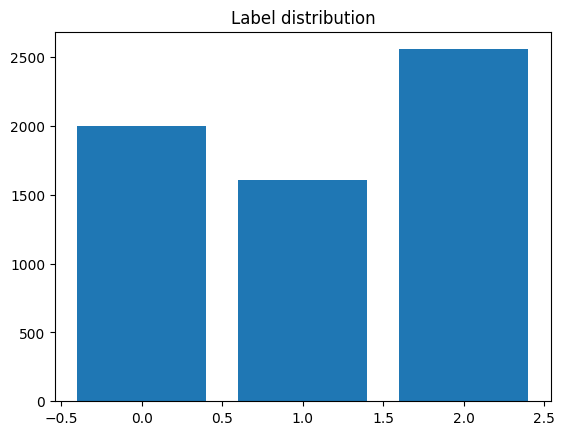

In [40]:
labels = [0, 1, 2]
label_cnt = [train_df[train_df["label_id"] == labels[i]].shape[0] for i in labels]

plt.title("Label distribution")
plt.bar(labels, label_cnt)
plt.show()

In [41]:
from transformers import AutoTokenizer, AutoModel
from torch.utils.data import Dataset, DataLoader, Subset
import torch.nn as nn
from sklearn.model_selection import KFold

kfold = KFold(n_splits=4, shuffle=True, random_state=42)

class ToxicDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=256):
        self.texts = texts
        self.labels = labels
        self.max_len = max_len
        self.tokenizer = tokenizer
        

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        tokens = self.tokenizer(str(self.texts[idx]), padding="max_length", truncation=True, max_length=self.max_len, return_tensors="pt")
        label = self.labels[idx]
        label = torch.tensor(label, dtype=torch.long)

        
        return{
            'input_ids': tokens['input_ids'].flatten(),
            'attention_mask': tokens['attention_mask'].flatten(),
            'labels': label
        }

BATCH_SIZE = 64
tokenizer = AutoTokenizer.from_pretrained("vinai/phobert-base")
train_ds = ToxicDataset(filtered_train_df["free_text"], filtered_train_df["label_id"], tokenizer)
test_ds = ToxicDataset(filtered_test_df["free_text"], filtered_test_df["label_id"], tokenizer)


# train_loader = DataLoader(train_ds, batch_size = BATCH_SIZE, shuffle = True, num_workers=4, pin_memory=True)
# test_loader = DataLoader(test_ds, batch_size = BATCH_SIZE, shuffle = False, num_workers=4, pin_memory=True)



class ToxicClassifier(nn.Module):
    def __init__(self, hidden_size=512):
        super().__init__()
        self.pho_bert = AutoModel.from_pretrained("vinai/phobert-base")
        
        for name, param in self.pho_bert.named_parameters():
            if "encoder.layer.10" in name or "encoder.layer.11" in name or "pooler" in name:
                param.requires_grad = True
            else:
                param.requires_grad = False
        
        self.classifier = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(768, hidden_size),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(hidden_size, 3)
        )

    def forward(self, inp, atn_msk):
        x = self.pho_bert(input_ids=inp, attention_mask=atn_msk)
        x = self.classifier(x.last_hidden_state[:, 0, :])
        return x



# Training

In [42]:
from sklearn.metrics import precision_recall_fscore_support
from tqdm import tqdm
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from transformers import get_linear_schedule_with_warmup

EPOCHS = 5
LR = 2e-5
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BATCH_SIZE = 64


train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

# Model Setup
model = ToxicClassifier()
model.to(DEVICE)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=0.01)
total_steps = len(train_loader) * EPOCHS
scheduler = get_linear_schedule_with_warmup(optimizer, num_warmup_steps=int(0.1 * total_steps), num_training_steps=total_steps)

# For later visualization
all_f1, all_recall, all_precision, all_train_loss, all_val_loss = [], [], [], [], []
best_f1 = 0

# 2. No K-Fold loop. Just loop over your Epochs.
for epoch in range(EPOCHS):
    print(f"\n---------------- EPOCH {epoch+1}/{EPOCHS} ----------------------")
    
    # --- TRAINING PHASE ---
    model.train()
    train_total_loss = 0
    progress_bar = tqdm(train_loader, desc="Training:")
    
    for batch in progress_bar:
        input_ids = batch["input_ids"].to(DEVICE)
        attention_mask = batch["attention_mask"].to(DEVICE)
        labels = batch['labels'].to(DEVICE)

        optimizer.zero_grad()
        logits = model(inp=input_ids, atn_msk=attention_mask)
        
        loss = criterion(logits.view(-1, 3), labels.view(-1))
        loss.backward()
        optimizer.step()
        scheduler.step()

        train_total_loss += loss.item()
        progress_bar.set_postfix({'loss': loss.item()})

    # --- EVALUATION PHASE ---
    model.eval() # CRITICAL: Put model in eval mode for validation
    val_total_loss = 0
    val_correct_cnt = 0
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for batch in tqdm(val_loader, desc="Evaluating: "):
            input_ids = batch["input_ids"].to(DEVICE)
            attention_mask = batch["attention_mask"].to(DEVICE)
            labels = batch['labels'].to(DEVICE)

            logits = model(inp=input_ids, atn_msk=attention_mask)
            preds = torch.argmax(logits.view(-1, 3), dim = -1)
            val_correct_cnt += (preds == labels).sum().item()

            val_total_loss += criterion(logits.view(-1, 3), labels.view(-1)).item() # Added .item() here

            all_preds.extend(preds.cpu().numpy().flatten())
            all_labels.extend(labels.cpu().numpy().flatten())

    # --- METRICS & SAVING ---
    val_accuracy = val_correct_cnt / len(filtered_test_df) 
    precision, recall, f1, _ = precision_recall_fscore_support(all_labels, all_preds, average='weighted', zero_division=0)
    
    print(f"Train Loss = {train_total_loss / len(train_loader) :.4f} ; Val Loss = {val_total_loss / len(val_loader) :.4f} ; Val Acc = {val_accuracy:.4f}")
    print(f"Precision: {precision:.4f} | Recall: {recall:.4f} | F1-Score: {f1:.4f}")

    all_train_loss.append(train_total_loss / len(train_loader))
    all_val_loss.append(val_total_loss / len(val_loader))
    all_f1.append(f1)
    all_recall.append(recall)
    all_precision.append(precision)

    if f1 > best_f1:
        best_f1 = f1
        torch.save(model.state_dict(), "best_model.pth")
        print("Saved best model!")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: vinai/phobert-base
Key                             | Status     |  | 
--------------------------------+------------+--+-
lm_head.dense.weight            | UNEXPECTED |  | 
roberta.embeddings.position_ids | UNEXPECTED |  | 
lm_head.decoder.bias            | UNEXPECTED |  | 
lm_head.decoder.weight          | UNEXPECTED |  | 
lm_head.layer_norm.bias         | UNEXPECTED |  | 
lm_head.bias                    | UNEXPECTED |  | 
lm_head.layer_norm.weight       | UNEXPECTED |  | 
lm_head.dense.bias              | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



---------------- EPOCH 1/5 ----------------------


Evaluating: 100%|██████████| 42/42 [00:33<00:00,  1.24it/s]


Train Loss = 1.0589 ; Val Loss = 1.0640 ; Val Acc = 0.4768
Precision: 0.8096 | Recall: 0.4768 | F1-Score: 0.5452
Saved best model!

---------------- EPOCH 2/5 ----------------------


...

Train Loss = 0.8917 ; Val Loss = 0.8296 ; Val Acc = 0.6838
Precision: 0.8170 | Recall: 0.6838 | F1-Score: 0.7253
Saved best model!

---------------- EPOCH 4/5 ----------------------


Evaluating: 100%|██████████| 42/42 [00:33<00:00,  1.25it/s]


Train Loss = 0.8605 ; Val Loss = 0.7804 ; Val Acc = 0.7040
Precision: 0.8227 | Recall: 0.7040 | F1-Score: 0.7420
Saved best model!

---------------- EPOCH 5/5 ----------------------


Evaluating: 100%|██████████| 42/42 [00:33<00:00,  1.25it/s]

Train Loss = 0.8472 ; Val Loss = 0.7941 ; Val Acc = 0.6912
Precision: 0.8232 | Recall: 0.6912 | F1-Score: 0.7331


# Visualization

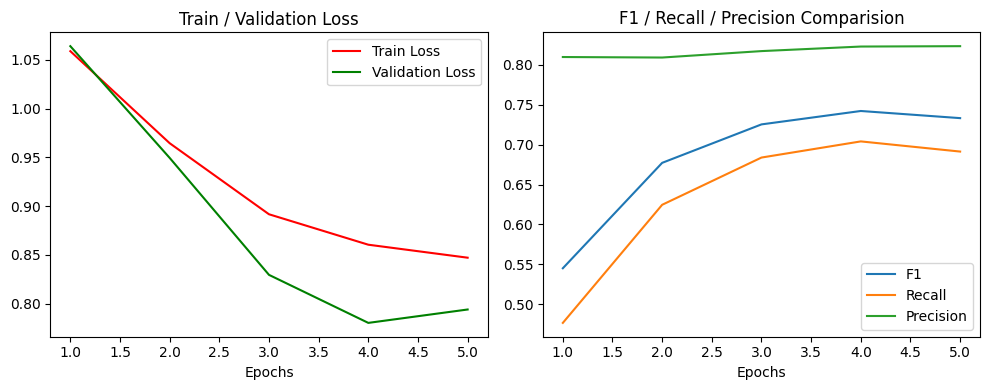

In [43]:

fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(10, 4))
num_epochs = np.arange(1, EPOCHS+1)

# print(num_epochs)
# all_val_loss = [i.cpu() for i in all_val_loss]

# First subplot (Left)
ax[0].plot(num_epochs, all_train_loss, color='red', label="Train Loss")
ax[0].plot(num_epochs, all_val_loss, color='green', label="Validation Loss")
ax[0].set_title('Train / Validation Loss')
ax[0].set_xlabel('Epochs')
ax[0].legend()

# Second subplot (Right)
ax[1].set_title('F1 / Recall / Precision Comparision')
ax[1].plot(num_epochs, all_f1, label="F1")
ax[1].plot(num_epochs, all_recall, label="Recall")
ax[1].plot(num_epochs, all_precision, label="Precision")
ax[1].set_xlabel('Epochs')
ax[1].legend()


# Optimize padding between graphs
plt.tight_layout()
plt.show()
